# Spaceship Titanic Model

## 1. Introduction

**Context**

Welcome to the year 2912. Humanity has reached the stars, and lost passengers need help to recover in a mysterious interdimensional incident.

The Spaceship Titanic, an interstellar vessel carrying over 13,000 emigrants to habitable exoplanets, suffered a tragic event near Alpha Centauri. A collision with a hidden spacetime anomaly caused nearly half of the passengers to be transported to an alternate dimension.

Fortunately, the ship’s damaged systems retained partial data. The mission is to use this data to build a predictive model that can identify which passengers were transported. This work will guide rescue efforts and potentially save thousands of lives.

**Goals:**

To build a binary classification model that predicts whether a passenger was Transported (True or False) using the features available in the dataset.

This is a classic supervised machine learning problem with tabular data, and predictions will be evaluated based on classification accuracy on the test set.  

**Objectives:**

Explore, clean, and preprocess the dataset.

Train several machine learning models.

Use techniques such as cross-validation, hyperparameter tuning, and ensembling to boost performance.

Submit predictions to Kaggle following the required format.

Achieve an accuracy score of at least 0.79 on the leaderboard.


## 2. Exploratory Data Analysis (EDA)

### A. Data loading & Initial checks

In [1]:
%load_ext jupyter_black

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import shap
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import (
    levene,
    chi2_contingency,
    randint,
    uniform,
    shapiro,
    mannwhitneyu,
)
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    make_scorer,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
)
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as imbPipeline
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    FunctionTransformer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.ensemble import (
    GradientBoostingClassifier,
    VotingClassifier,
    RandomForestClassifier,
)
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_predict,
    cross_validate,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from typing import Dict, Optional, List, Tuple, Union
from imblearn.over_sampling import SMOTE
from optuna.samplers import TPESampler
from phik import phik_matrix, resources, report
from phik.binning import bin_data
from phik.report import plot_correlation_matrix
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.base import BaseEstimator, clone
import joblib
import warnings
import logging
import random
import re
import phik
import pickle
import os
from flaml import AutoML

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("tableau-colorblind10")
optuna.logging.set_verbosity(optuna.logging.WARNING)
random.seed(42)
np.random.seed(42)

In [3]:
from Data.utils_preprocessing import (
    bootstrap_median_diff,
    calculate_vif,
    extract_title,
    tune_xgboost,
    tune_lightgbm,
    create_calibrated_ensemble,
    crosstab_chi2_test,
)
from Data.utils_vizualization import (
    plot_distribution_numerical,
    stacked_bar_with_percent,
    plot_transported_distribution,
    plot_phik_correlation_heatmap,
    plot_metrics_comparison,
    analyze_shap,
    plot_model_metrics_comparison,
    evaluate_model_on_test,
    plot_calibration_comparison,
)

In [4]:
df_original = pd.read_csv(r"Data\train.csv")
df = df_original.copy()
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
df.shape

(8693, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


**Feature descriptions:**


    PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
    
    HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
    
    CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
   
    Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
    
    Destination - The planet the passenger will be debarking to.
    
    Age - The age of the passenger.
    
    VIP - Whether the passenger has paid for special VIP service during the voyage.
    
    RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
    
    Name - The first and last names of the passenger.
    
    Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

In [7]:
categorical = df.select_dtypes(include="object").columns.tolist()
numerical = df.select_dtypes(exclude="object").columns.tolist()
binary = [col for col in df.columns if df[col].nunique() == 2]

print(f"Numerical features: {numerical}")
print(f"Categorical features: {categorical}")
print(f"Binary features: {binary}")

Numerical features: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported']
Categorical features: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
Binary features: ['CryoSleep', 'VIP', 'Transported']


In [8]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


**Key Insights:**

Age Distribution:

    The average age is about 28.8 years. A wide age range is present, from 0 to 79 years.

Expenditure Patterns (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck):

    High Proportion of Non-Spenders: For all expenditure categories, the minimum value, 25th percentile, and 50th percentile (median) are 0. This strongly indicates that a very large portion of the population spent nothing in these categories.

    Highly Skewed Distributions: The mean values are significantly higher than the median (0), and the standard deviations are very large compared to the means. This suggests that while many people spent nothing, a small number of individuals made extremely high expenditures in these categories, pulling the average up.

    Variability in Max Spending: Maximum spending varies across categories, with 'FoodCourt' showing the highest single expenditure at 29,813.

**Checking for missing values.**

In [9]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [10]:
df.isna().sum() / len(df) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

In [11]:
df_no_Na = df.dropna()
missing_rows = df.shape[0] - df_no_Na.shape[0]
percentage_missing = missing_rows / df.shape[0] * 100
print(
    f"Missing rows: {missing_rows} of {df.shape[0]} total rows in data set."
    f"\nMissing rows %: {percentage_missing:.2f}"
)

Missing rows: 2087 of 8693 total rows in data set.
Missing rows %: 24.01


Although solo features have less than 2.5% missing values, dropping all NaNs would result in losing 24% of the rows in the dataset. Therefore, we'll use an imputer.

**Checking for duplicates.**

In [12]:
print(
    f"Duplicates: {df.duplicated().sum()}, {(df.duplicated().sum() / len(df) * 100):.2f}%"
)

Duplicates: 0, 0.00%


No duplicates in dataset.

### B. Univariate Analysis

**Distribution of target variable - Transported**

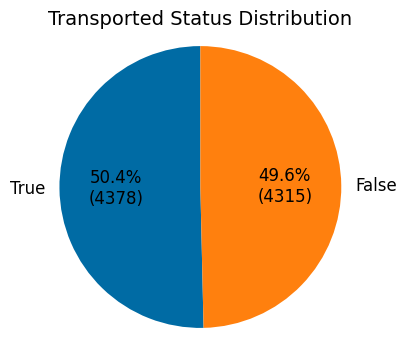

In [13]:
plot_transported_distribution(df)

The two categories ("True" and "False") are almost evenly distributed. This indicates a very balanced data set or outcome, where neither category significantly dominates the other.

**Distribution plots for numerical features.**

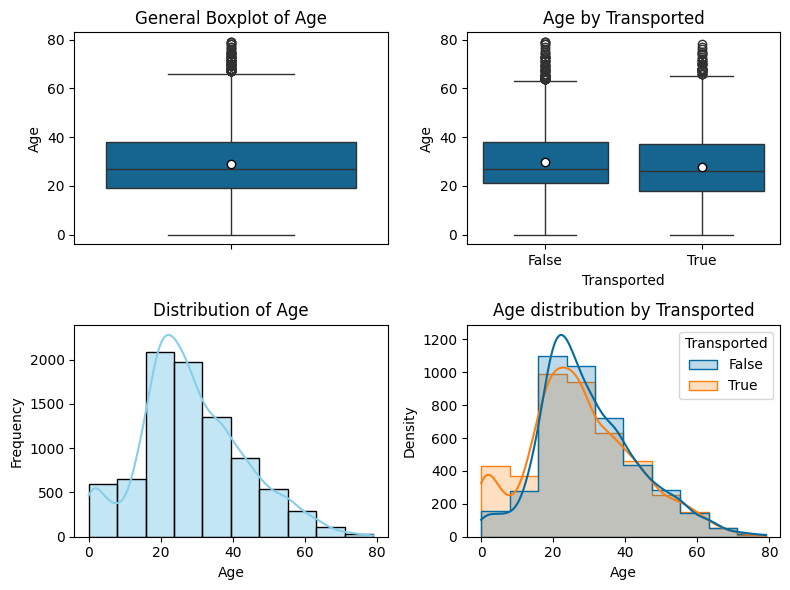

In [14]:
plot_distribution_numerical(df, column="Age")

The age distribution is close to normal, right skewed,. Outliers above 63 years old. A substantial number of observations are concentrated within the 18-35 age range, no significant anomalies were detected.

In the group of young people under 16 years of age, there are more individuals who were transported than those who were not. Mean and median for transported individuals are also lower. This indicates that age could be a valuable feature for transported prediction.

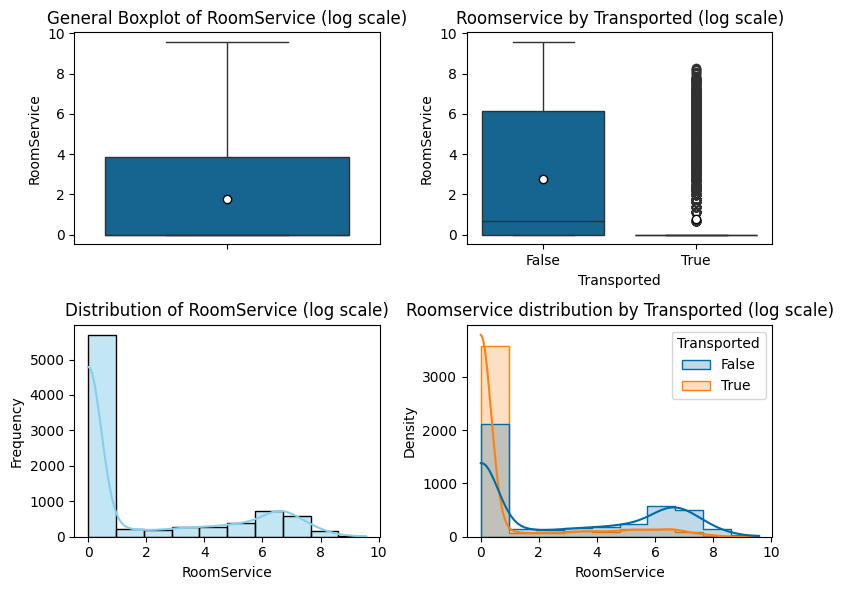

In [15]:
plot_distribution_numerical(df, column="RoomService", log_scale=True)

RoomService distribution is not normal, right skewed (log scale). Mean and median for transported individuals are much more lower, therefore there are a lot of outliers in transported group. Among the transported individuals, the largest group had expenditures of 0 or close to 0. No other anomalies were detected.

RoomService could be a valuable feature for predicting whether the individual was transported or not.

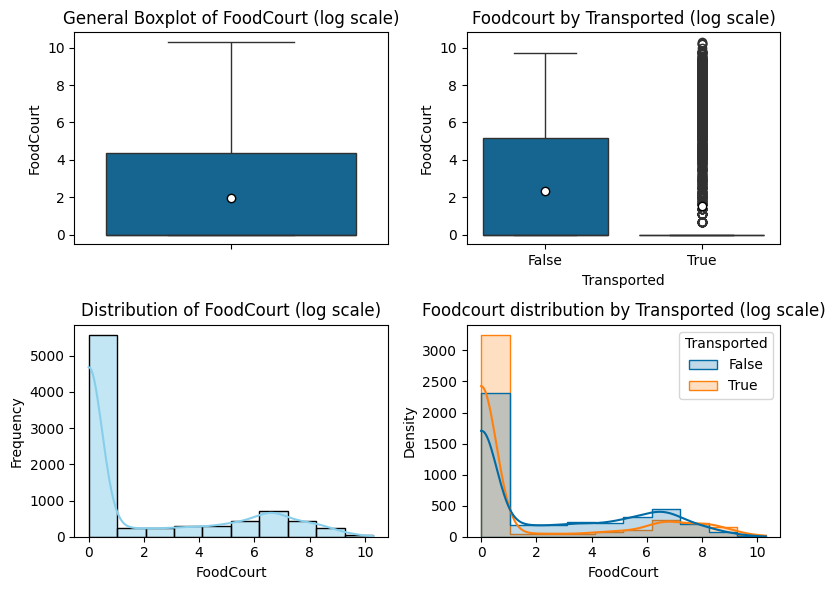

In [16]:
plot_distribution_numerical(df, column="FoodCourt", log_scale=True)

FoodCourt distribution is not normal, right skewed (log scale). Mean and median for transported individuals are much more lower, therefore there are a lot of outliers in transported group. Among the transported individuals, the largest group had expenditures of 0 or close to 0. No other anomalies were detected.

FoodCourt could be a valuable feature for predicting whether the individual was transported or not.

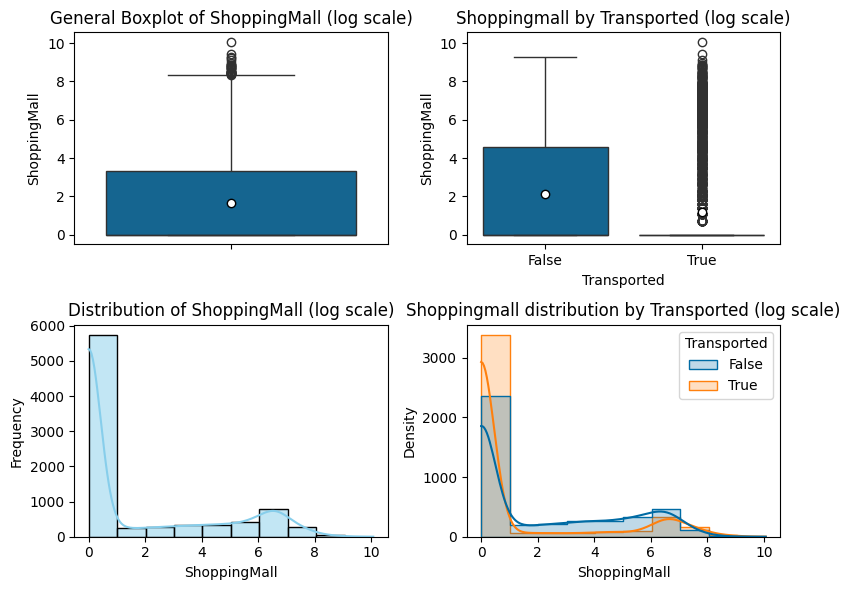

In [17]:
plot_distribution_numerical(df, column="ShoppingMall", log_scale=True)

ShoppingMall distribution is not normal, right skewed (log scale). Mean and median for transported individuals are much more lower, therefore there are a lot of outliers in transported group. Among the transported individuals, the largest group had expenditures of 0 or close to 0. No other anomalies were detected.

ShoppingMall could be a valuable feature for predicting whether the individual was transported or not.

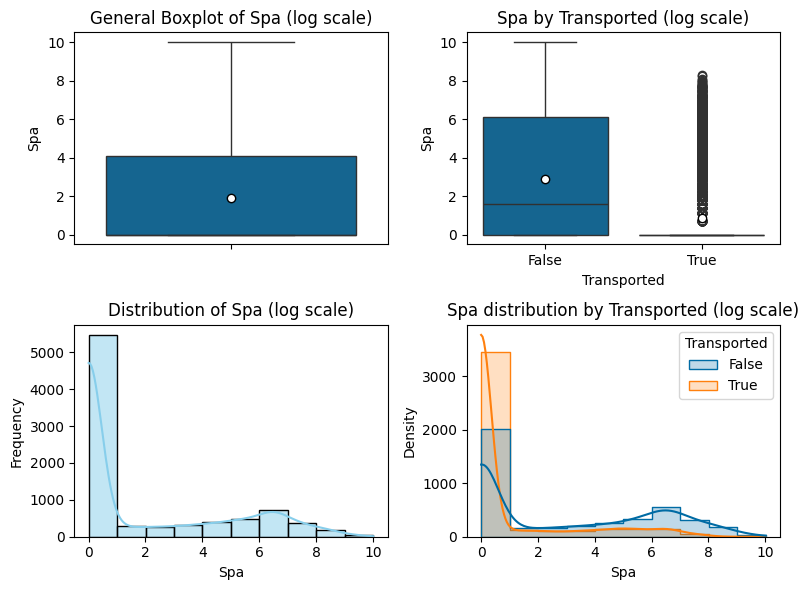

In [18]:
plot_distribution_numerical(df, column="Spa", log_scale=True)

Spa distribution is not normal, right skewed (log scale). Mean and median for transported individuals are much more lower, therefore there are a lot of outliers in transported group. Among the transported individuals, the largest group had expenditures of 0 or close to 0. No other anomalies were detected.

Spa could be a valuable feature for predicting whether the individual was transported or not.

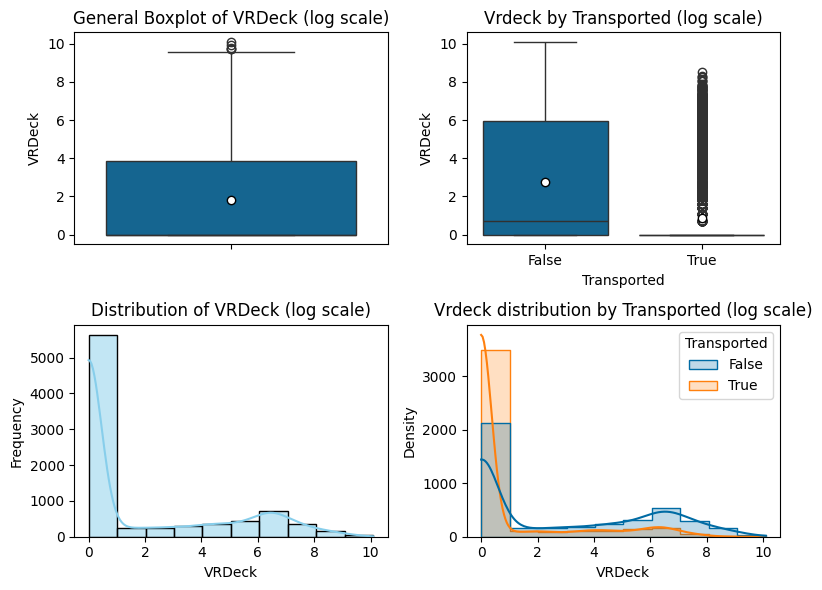

In [19]:
plot_distribution_numerical(df, column="VRDeck", log_scale=True)

VRDeck distribution is not normal, right skewed (log scale). Mean and median for transported individuals are much more lower, therefore there are a lot of outliers in transported group. Among the transported individuals, the largest group had expenditures of 0 or close to 0. No other anomalies were detected.

VRDeck could be a valuable feature for predicting whether the individual was transported or not.

**Countplots for categorical features**

In [20]:
df["HomePlanet"].value_counts(normalize=True)

HomePlanet
Earth     0.541922
Europa    0.250942
Mars      0.207136
Name: proportion, dtype: float64

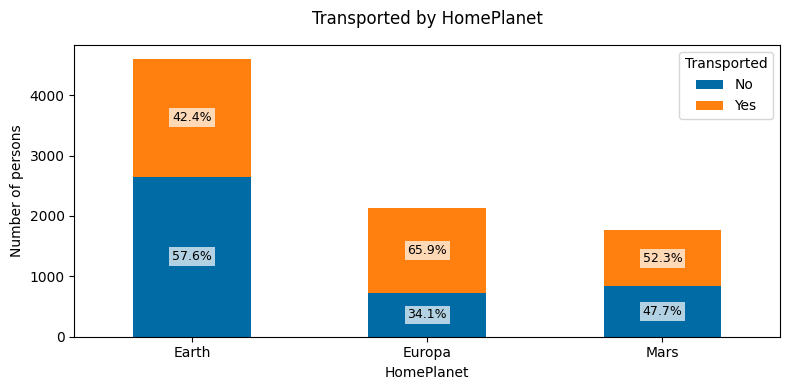

In [21]:
stacked_bar_with_percent(df, column_x="HomePlanet")

While most people's home planet was Earth (54%), the transportation ratio for Earth was the smallest at 42.4%. The highest transportation ratio, was observed for Europa 65,9%.

In [22]:
df["CryoSleep"].value_counts(normalize=True)

CryoSleep
False    0.641694
True     0.358306
Name: proportion, dtype: float64

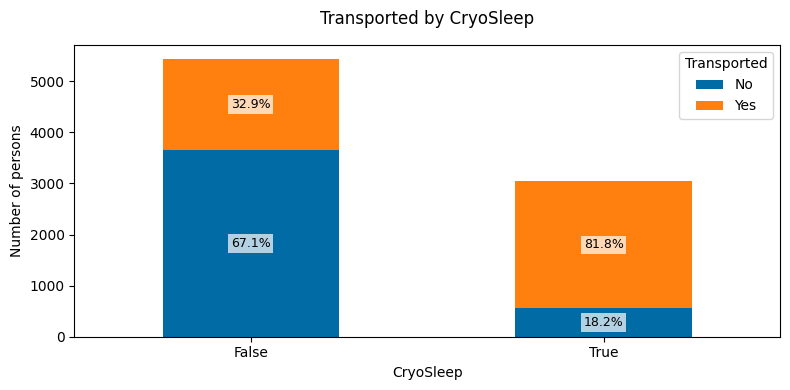

In [23]:
stacked_bar_with_percent(df, column_x="CryoSleep")

The majority of individuals were not in CryoSleep (64%). 

There's a very strong positive correlation between being in CryoSleep and being transported.

    81.8% of individuals in CryoSleep were transported.

    Only 32.9% of individuals not in CryoSleep were transported.

CryoSleep could be a very important feature for predicting whether the individual was transported or not.

In [24]:
df["Destination"].value_counts(normalize=True)

Destination
TRAPPIST-1e      0.694983
55 Cancri e      0.211491
PSO J318.5-22    0.093526
Name: proportion, dtype: float64

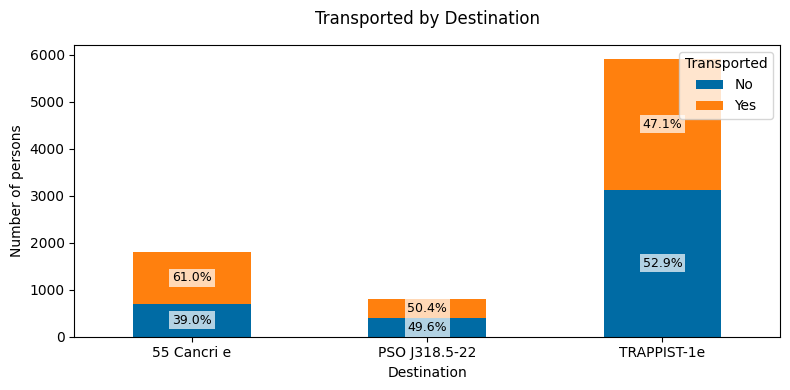

In [25]:
stacked_bar_with_percent(df, column_x="Destination")

TRAPPIST-1e is the most frequent destination, but it has the lowest transportation rate at 47.1%.

55 Cancri e is the less frequent destination, but it boasts the highest transportation rate at 61%.

PSO J318.5-22 is the least common destination and has a moderate transportation rate.

In [26]:
df["VIP"].value_counts(normalize=True)

VIP
False    0.976561
True     0.023439
Name: proportion, dtype: float64

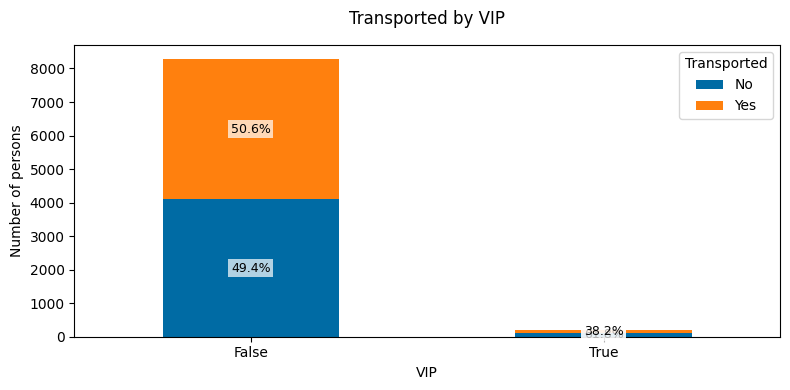

In [27]:
stacked_bar_with_percent(df, column_x="VIP")

A vast majority of individuals are not VIPs, and the transportation rate for them is 50.6%. 

Despite being a very small group, VIPs actually had a lower likelihood of being transported compared to non-VIP individuals. This suggests that VIP status, by itself, might not be a positive indicator for transportation in this context.

**"Cabin" feature**

In [28]:
df["Cabin"].value_counts(normalize=True)

Cabin
G/734/S     0.000942
G/109/P     0.000824
B/201/P     0.000824
G/1368/P    0.000824
G/981/S     0.000824
              ...   
G/556/P     0.000118
E/231/S     0.000118
G/545/S     0.000118
G/543/S     0.000118
F/947/P     0.000118
Name: proportion, Length: 6560, dtype: float64

Let look at every part of "Cabin" number.

In [29]:
df["Cabin"].str[0].value_counts()

Cabin
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

In [30]:
df["Cabin"].str.split("/").str[1].nunique()

1817

In [31]:
df["Cabin"].str[-1].value_counts()

Cabin
S    4288
P    4206
Name: count, dtype: int64

There are 8 unique deck letters (derived from the first letter of the Cabin number) and 2 unique side letters (derived from the last letter of the Cabin number). These can potentially be useful new features: 'Deck' and 'Side'.

The 'Cabin' number itself has many unique values and is probably not useful for direct feature engineering.

**"Name" feature**

In [32]:
df["Name"].nunique()

8473

In [33]:
print(
    f'Name word counts:\n{df["Name"].fillna("").str.split().apply(len).value_counts()}'
)

Name word counts:
Name
2    8493
0     200
Name: count, dtype: int64


Checking is there any titles.

In [34]:
df["Name"].apply(extract_title).value_counts()

Name
None    8693
Name: count, dtype: int64

Most of names are unique, no titles. Name feature is probably not useful for direct feature engineering.

**"PassengerId" feature**

In [35]:
df["PassengerId"].value_counts(normalize=True)

PassengerId
0001_01    0.000115
6136_01    0.000115
6141_01    0.000115
6139_06    0.000115
6139_05    0.000115
             ...   
3126_01    0.000115
3124_03    0.000115
3124_02    0.000115
3124_01    0.000115
9280_02    0.000115
Name: proportion, Length: 8693, dtype: float64

In [36]:
Group = df["PassengerId"].str.split("_").str[0]
Group.value_counts()

PassengerId
4498    8
8168    8
8728    8
8796    8
8956    8
       ..
3483    1
3480    1
3478    1
3473    1
4620    1
Name: count, Length: 6217, dtype: int64

In [37]:
group_sizes = Group.value_counts()
GroupSize = Group.map(group_sizes)
IsSolo = (GroupSize == 1).astype(int)
IsSolo.value_counts()

PassengerId
1    4805
0    3888
Name: count, dtype: int64

Many passengers belong to the same group (likely family or travel companions). People in the same group may have similar survival outcomes.
Solo travelers (GroupSize = 1) might have different survival rates than families.

PassengerId feature could be useful for direct feature engineering.

**Univariate Analysis summary**

    CryoSleep appears to be the most important metric. 

    Age and individual expenditures are also important features. 
    
    While 'PassengerId' is a unique identifier and the full 'Cabin' number might not be directly useful for feature engineering, components like 'Deck' and 'Side' derived from 'Cabin' could be valuable. 
    
    'VIP' status and 'Name' might not be as important for direct feature engineering.

### C. Multivariate Analysis

**Phi-k Correlation matrix**

interval columns not set, guessing: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


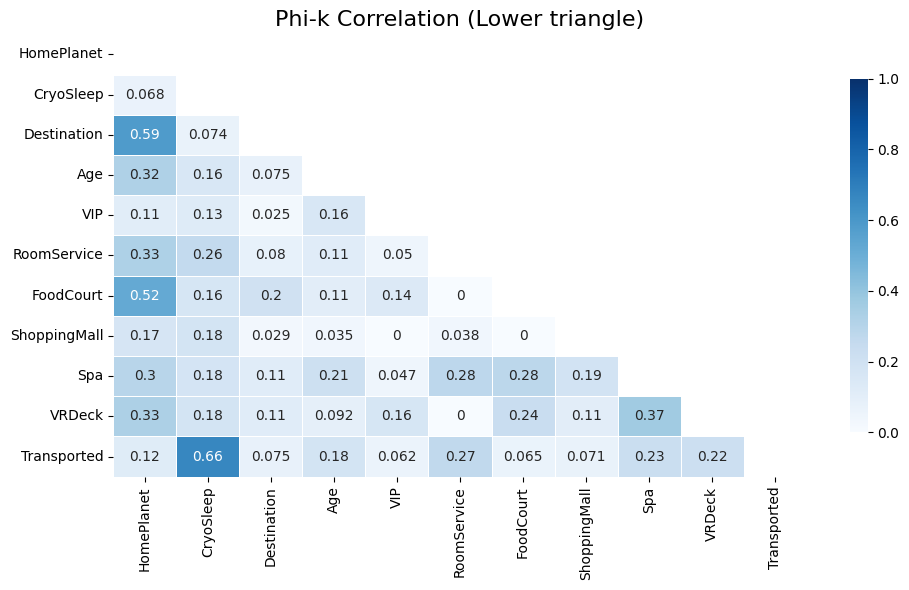

In [38]:
df_phik = df_no_Na.drop(columns=["PassengerId", "Cabin", "Name"])
plot_phik_correlation_heatmap(df_phik)

The most significant factors influencing Transported status are:

    CryoSleep (0.66): This is by far the strongest predictor, indicating a very high dependency on whether a person was in cryosleep.

    RoomService (0.27), Spa (0.23), and VRDeck (0.22): These spending categories also show a moderate level of dependency.

    Age (0.18): Age has a noticeable, though weaker, dependency.

Features with low dependency include:

    HomePlanet (0.12), Destination (0.075), FoodCourt (0.065), ShoppingMall (0.071), and VIP (0.062): These features show very little relationship with the Transported status.

**Multicollinearity check**

As the phi-K correlation matrix revealed strong dependencies among the independent variables, we will assess for multicollinearity.

In [39]:
calculate_vif(df_no_Na, target_column="Transported")

,feature,VIF
0,const,5.04
1,FoodCourt,1.10
2,Spa,1.07
3,VRDeck,1.07
4,Age,1.04
5,RoomService,1.01
6,ShoppingMall,1.01


All non-constant features have VIF < 2. No significant multicollinearity.

## 3. Statistical Inference

**1. Target Population**

*Target population:* all potential passengers that could be part of the scenario this data represents.

*Sample size:* 8,693 individuals included in the data set.

    Numerical features: 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'.

    Categorical features: 'PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name'.

The target variable is Transported (binary: False / True).

We want to infer about relationships between features and "Transported" status.

We'll examine these relationships with threshold for statistical significance α = 0.05.

**2. Hypotheses testing**

**Hypothesis 1: Average age differs between transported and not transported individuals**

Null Hypothesis (H₀): The mean age of transported and not transported individuals is the same.

**Alternative Hypothesis (H₁): The mean age of transported and not transported individuals differs.**

- Test: Two-sample t-test
- Assumptions: Independent samples (no duplicates), approximately normal distribution or large sample, equal variances.

**Checking for normality.**

Using the Shapiro-Wilk test.

Null Hypothesis (H₀): Sample looks normal. 
Alternative Hypothesis (H₁): Sample does not look normal.

In [40]:
df = df_no_Na.copy()
df["Transported_bin"] = df["Transported"].astype(int)

Transported_0 = df[df["Transported_bin"] == 0]["Age"]
Transported_1 = df[df["Transported_bin"] == 1]["Age"]

stat_yes, p_yes = shapiro(Transported_1)
stat_no, p_no = shapiro(Transported_0)

print(f"Transported (1 - Yes) - p-value: {p_yes:.4f}")
print(f"Transported (0 -  No) - p-value: {p_no:.4f}")

Transported (1 - Yes) - p-value: 0.0000
Transported (0 -  No) - p-value: 0.0000


Both p-values < 0.05: Reject H₀ - Samples does not look normal.

**Checking for equal variances.**

Null Hypothesis (H₀): The variances of average age of individuals is the same for transported and not transported.

Alternative Hypothesis (H₁): The variances of average age of individuals differs between transported and not transported.

In [41]:
stat, p = levene(Transported_0, Transported_1)
print(f"Levene's p-value: {p:.4f}")

Levene's p-value: 0.0000


p-value < 0.05: Reject H₀ - variances are unequal.

Distributions are not normal and variances are unequal, the assumptions for a standard two-sample t-test are violated. We should not use the regular t-test.

**Using the Mann-Whitney U Test**

In [42]:
stat, p = mannwhitneyu(Transported_1, Transported_0, alternative="two-sided")
print(f"Mann-Whitney U Test p-value: {p:.4f}")

Mann-Whitney U Test p-value: 0.0000


P-value < 0.05. Reject H₀ -  The mean age of transported and not transported individuals differs.

**Bootstrap CI for the median difference**

In [43]:
bootstrap_ci = bootstrap_median_diff(Transported_1, Transported_0)
print(
    f"\nBootstrap CI for the median difference (Yes - No): [{bootstrap_ci[0]:.2f}, {bootstrap_ci[1]:.2f}]"
)


Bootstrap CI for the median difference (Yes - No): [-3.00, -1.00]


This interval does not include zero, reinforcing that the difference in medians is statistically significant. These results suggest the mean age of transported and not transported individuals differs.

**Hypothesis 2: Average VRDeck spending differs between transported and not transported individuals**

Null Hypothesis (H₀): Average VRDeck spending of transported and not transported individuals is the same.

**Alternative Hypothesis (H₁): Average VRDeck spending of transported and not transported individuals differs.**

**Checking for normality.**

Using the Shapiro-Wilk test.

Null Hypothesis (H₀): Sample looks normal. 
Alternative Hypothesis (H₁): Sample does not look normal.

In [44]:
Transported_VRD_0 = df[df["Transported_bin"] == 0]["VRDeck"]
Transported_VRD_1 = df[df["Transported_bin"] == 1]["VRDeck"]

stat_yes, p_yes = shapiro(Transported_VRD_1)
stat_no, p_no = shapiro(Transported_VRD_0)

print(f"Transported (1 - Yes) - p-value: {p_yes:.4f}")
print(f"Transported (0 -  No) - p-value: {p_no:.4f}")

Transported (1 - Yes) - p-value: 0.0000
Transported (0 -  No) - p-value: 0.0000


Both p-values < 0.05: Reject H₀ - Samples does not look normal.

**Checking for equal variances.**

Null Hypothesis (H₀): The variances of average VRDeck spending is the same for transported and not transported individuals.

Alternative Hypothesis (H₁): The variances of average VRDeck spending differs between transported and not transported individuals

In [45]:
stat, p = levene(Transported_VRD_0, Transported_VRD_1)
print(f"Levene's p-value: {p:.4f}")

Levene's p-value: 0.0000


p-value < 0.05: Reject H₀ - variances are unequal.

Distributions are not normal and variances are unequal, the assumptions for a standard two-sample t-test are violated. We should not use the regular t-test.

**Using the Mann-Whitney U Test**

In [46]:
stat, p = mannwhitneyu(Transported_VRD_1, Transported_VRD_0, alternative="two-sided")
print(f"Mann-Whitney U Test p-value: {p:.4f}")

Mann-Whitney U Test p-value: 0.0000


P-value < 0.05. Reject H₀ - The average VRDeck spending differs between transported and not transported individuals.

**Bootstrap CI for the median difference**

In [47]:
bootstrap_ci = bootstrap_median_diff(Transported_VRD_1, Transported_VRD_0)
print(
    f"\nBootstrap CI for the median difference (Yes - No): [{bootstrap_ci[0]:.2f}, {bootstrap_ci[1]:.2f}]"
)


Bootstrap CI for the median difference (Yes - No): [-3.00, 0.00]


Since this interval does not include zero and is entirely positive, it indicates that average VRDeck spending differs between transported and not transported individuals.

**Hypothesis 3: CryoSleep has no effect on whether an individual was transported.**

Null Hypothesis (H₀): There is no association between CryoSleep status and being transported.

**Alternative Hypothesis (H₁): There is association between CryoSleep status and being transported.**

- Test: Chi2 test.

In [48]:
crosstab_chi2_test(df=df, col_x="Transported", col_y="CryoSleep")


 Crosstab of Transported vs. CryoSleep

Normalized Crosstab (%):
CryoSleep    False  True 
Transported              
False         87.0   13.0
True          43.0   57.0

Chi-squared test results:
Chi-squared Statistic: 1412.9836
Degrees of Freedom: 1
P-value: 0.0000
 Statistically significant association (p < 0.05)


P-value < 0.05, There is a significant association between CryoSleep status and whether an individual was transported. The observed relationship is highly unlikely to have occurred by random chance.

**Statistical Inference summary**

Statistical tests demonstrate that individuals' average age, Average VRDeck spending, and CryoSleep status differ significantly between transported and not transported individuals.

## 4. Machine Learning Modeling

### A. Data Preparation and Feature Engineering

We will reset the data set.

In [49]:
df = df_original.copy()

print(
    f"{ df.shape},\n Duplicated: {df.duplicated().sum()}\n Missing values:\n{df.isna().sum().sum()}"
)

(8693, 14),
 Duplicated: 0
 Missing values:
2324


**Feature Engineering from PassengerId**

The PassengerId is in the format XXXX_XX, where: the first 4 digits represent a group/family. the last 2 digits represent the passenger's position within the group.

Many passengers belong to the same group (likely family or travel companions). People in the same group may have similar survival outcomes (if one was transported, others might be too).

GroupSize. Helps determine if a passenger was traveling alone or with others. Large groups might have higher/lower chances of being transported.

IsSolo. Solo travelers (GroupSize = 1) might have different survival rates than families.

In [51]:
df["Group"] = df["PassengerId"].str.split("_").str[0].astype(int)
group_sizes = df["Group"].value_counts()
df["GroupSize"] = df["Group"].map(group_sizes)
df["IsSolo"] = (df["GroupSize"] == 1).astype(int)

**Feature Engineering from Cabin**

Deck (Letters: A, B, C, ...). Different decks may have different transport probabilities. Some decks may have been more affected by the anomaly.

The 'Cabin' number itself has many unique values and can cause more noise.

Side (Port or Starboard). The side of the ship might have influenced survival.

In [52]:
df["Deck"] = df["Cabin"].str[0]
df["Side"] = df["Cabin"].str[-1]

**Feature Engineering from spending**

LuxurySpending: Sum of RoomService + Spa + VRDeck. Luxury spenders may have different outcomes.

EssentialSpending: Sum of FoodCourt + ShoppingMall. Necessities vs. luxury.

Total_spend: Total expenditure.

CryoSleep_NoSpend:  Binary flag for CryoSleep + Zero spending.

In [53]:
df["LuxurySpending"] = df["RoomService"] + df["Spa"] + df["VRDeck"]
df["EssentialSpending"] = df["FoodCourt"] + df["ShoppingMall"]
df["Total_spend"] = df["LuxurySpending"] + df["EssentialSpending"]
df["CryoSleep_NoSpend"] = (df["CryoSleep"] & (df["Total_spend"] == 0)).astype(int)

**Feature Engineering interaction**

AvgGroupSpending: Mean spending per group. Groups with high spending may have different fates.

In [54]:
df["AvgGroupSpending"] = df.groupby("Group")["Total_spend"].transform("mean")

In [55]:
df.head(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Group,GroupSize,IsSolo,Deck,Side,LuxurySpending,EssentialSpending,Total_spend,CryoSleep_NoSpend,AvgGroupSpending
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,1,1,1,B,P,0.0,0.0,0.0,0,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,2,1,1,F,S,702.0,34.0,736.0,0,736.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,3,2,0,A,S,6807.0,3576.0,10383.0,0,7779.5


In [56]:
df.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'Group', 'GroupSize', 'IsSolo', 'Deck', 'Side',
       'LuxurySpending', 'EssentialSpending', 'Total_spend',
       'CryoSleep_NoSpend', 'AvgGroupSpending'],
      dtype='object')

**Splitting the data**

Dropping unnecessary columns

In [57]:
X = df.drop(
    columns=[
        "Transported",
        "Name",
        "PassengerId",
        "Cabin",
        "RoomService",
        "Spa",
        "VRDeck",
        "FoodCourt",
        "ShoppingMall",
    ],
)
y = df["Transported"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 6954 samples, Test: 1739 samples


### B. Pipeline Preprocessing 

Given the presence of NaN values, we will handle them using a SimpleImputer: 'most_frequent' strategy for categorical features and 'median' for numerical features (due to their skewed distribution). 

Categorical columns will then be processed with OneHotEncoder (with the option drop="if_binary" to drop unnecessary columns if the feature is binary.), and numerical columns with RobustScaler.

**Defining preprocesor**

In [58]:
categorical = X_train.select_dtypes(include="object").columns.tolist()
numerical = X_train.select_dtypes(exclude="object").columns.tolist()

cat_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                drop="if_binary", handle_unknown="ignore", sparse_output=False
            ),
        ),
    ]
)
num_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", RobustScaler()),
    ]
)

preprocessor = ColumnTransformer(
    [("num", num_pipe, numerical), ("cat", cat_pipe, categorical)]
)

### C. Model Selection

We will use LogisticRegression, XGBoost, LightGBM, Random Forest.

Logistic Regression

    A linear model for binary classification.

    Fast, interpretable, and good baseline for performance comparison.

XGBoost (Extreme Gradient Boosting)

    Optimized gradient boosting algorithm.

    Known for speed and performance on structured/tabular data.

LightGBM (Light Gradient Boosting Machine)

    Gradient boosting by Microsoft, optimized for large datasets.

    Fast training with lower memory usage; supports categorical features.

Random Forest

    Strong baseline. Robust to overfitting.
    
    Handles missing values (to some extent) and categorical encoding well

In [59]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=1,
        tree_method="hist",
    ),
    "Random Forest": RandomForestClassifier(random_state=42, max_features="sqrt"),
    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=1,
        verbose=-1,
    ),
}

**Most Important Metrics**

1.	Accuracy (Primary Metric)

        The competition evaluates submissions on accuracy (percentage of correct predictions).
        Aim for ≥0.79 to be competitive.
  
2.	ROC AUC (Area Under the ROC Curve)

        Measures how well the model separates the classes (Transported vs. Not Transported).
        Great for tuning thresholds and comparing models.
  
3.	F1-Score (Class 1: "Transported")

        Balances precision and recall for the positive class.
        Use F1 for class "1" (Transported).
  
4.	Confusion Matrix

        Gives insight into types of errors.

**Results for default models (before hyperparameters tuning)**

In [60]:
detailed_reports = {}
overall_metrics = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_scores = np.zeros(len(X_train))

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        pipe.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_scores[val_idx] = pipe.predict_proba(X_train.iloc[val_idx])[:, 1]

    y_pred_labels = (y_scores > 0.5).astype(int)

    report = classification_report(y_train, y_pred_labels, output_dict=True)
    roc_auc = roc_auc_score(y_train, y_scores)  # No [:, 1] needed!

    detailed_reports[name] = pd.DataFrame(report).transpose()
    overall_metrics[name] = {
        "Accuracy": report["accuracy"],
        "ROC AUC": roc_auc,
        "F1 (1)": report["1"]["f1-score"],
    }

    print(
        f"=== {name} ===\n"
        f"{classification_report(y_train, y_pred_labels)}"
        f"ROC AUC: {roc_auc:.4f}\n" + "-" * 30
    )

print("\n=== Overall Model Metrics ===")
overall_metrics_df = pd.DataFrame.from_dict(overall_metrics, orient="index")
print(overall_metrics_df.round(4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.77      0.78      3452
           1       0.78      0.80      0.79      3502

    accuracy                           0.79      6954
   macro avg       0.79      0.79      0.79      6954
weighted avg       0.79      0.79      0.79      6954
ROC AUC: 0.8729
------------------------------
=== XGBoost ===
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      3452
           1       0.81      0.79      0.80      3502

    accuracy                           0.80      6954
   macro avg       0.80      0.80      0.80      6954
weighted avg       0.80      0.80      0.80      6954
ROC AUC: 0.8890
------------------------------
=== Random Forest ===
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      3452
           1       0.81      0.77      0.79      3502

    accuracy            

**Ploting models performances**

<Figure size 1000x600 with 0 Axes>

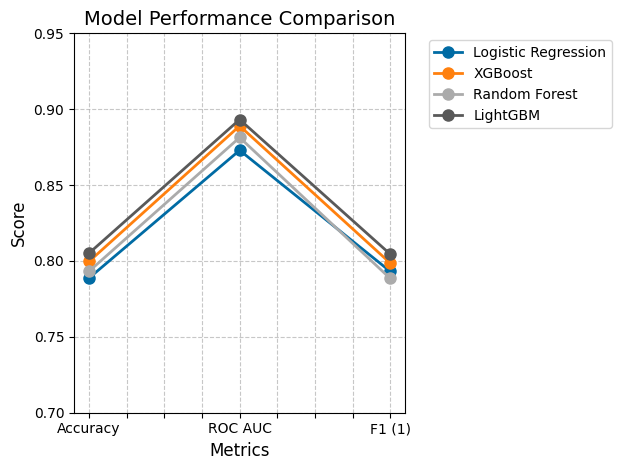

In [61]:
metrics_to_plot = overall_metrics_df.T

plt.figure(figsize=(10, 6))
metrics_to_plot.plot(marker="o", linestyle="-", linewidth=2, markersize=8)

plt.title("Model Performance Comparison", fontsize=14)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(0.7, 0.95)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

For further tuning we will choose two best models: LightGBN and XGBoost.

### D. Hyperparameter Tuning

Using Optuna for tuning models hyperparameters to maximize the accuracy score.

**Tuning XGBoost**

In [62]:
best_model_xgb, preprocessor_xgb, metrics_xgb = tune_xgboost(
    X_train, y_train, n_trials=50
)
print("\nTuned Metrics XGBoost:")
print(f"Accuracy: {metrics_xgb['accuracy']:.4f}")
print(f"ROC AUC: {metrics_xgb['roc_auc']:.4f}")
print(f"F1-Score: {metrics_xgb['f1']:.4f}")
print(f"Best Iteration: {metrics_xgb['best_iteration']}")
print(f"Best Parameters: {metrics_xgb['best_params']}")

  0%|          | 0/50 [00:00<?, ?it/s]


Tuned Metrics XGBoost:
Accuracy: 0.8385
ROC AUC: 0.9235
F1-Score: 0.8397
Best Iteration: 417
Best Parameters: {'max_depth': 5, 'learning_rate': 0.08026520743181652, 'subsample': 0.7714096477284144, 'colsample_bytree': 0.6034656523865062, 'gamma': 0.2861090668487686, 'reg_alpha': 1.3649604157119983, 'reg_lambda': 0.751173572115069, 'min_child_weight': 18}


**Tuning LightGBM**

In [63]:
best_model_lgbm, preprocessor_lgbm, metrics_lgbm = tune_lightgbm(
    X_train, y_train, n_trials=50
)
print("\nFinal Metrics LightGBM:")
print(f"Accuracy: {metrics_lgbm['accuracy']:.4f}")
print(f"ROC AUC: {metrics_lgbm['roc_auc']:.4f}")
print(f"F1-Score: {metrics_lgbm['f1']:.4f}")
print(f"Best Iteration: {metrics_lgbm['best_iteration']}")
print(f"Best Parameters: {metrics_lgbm['best_params']}")

  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[561]	valid_0's binary_logloss: 0.404101

Final Metrics LightGBM:
Accuracy: 0.8451
ROC AUC: 0.9315
F1-Score: 0.8483
Best Iteration: 561
Best Parameters: {'max_depth': 4, 'num_leaves': 64, 'learning_rate': 0.04725790829307527, 'subsample': 0.688472909864462, 'colsample_bytree': 0.6743700563573016, 'reg_alpha': 0.7696160841858243, 'reg_lambda': 0.7232523275377434, 'min_child_samples': 21}


**Comparing metrics for XGBoost and LightGBM before and after tuning**

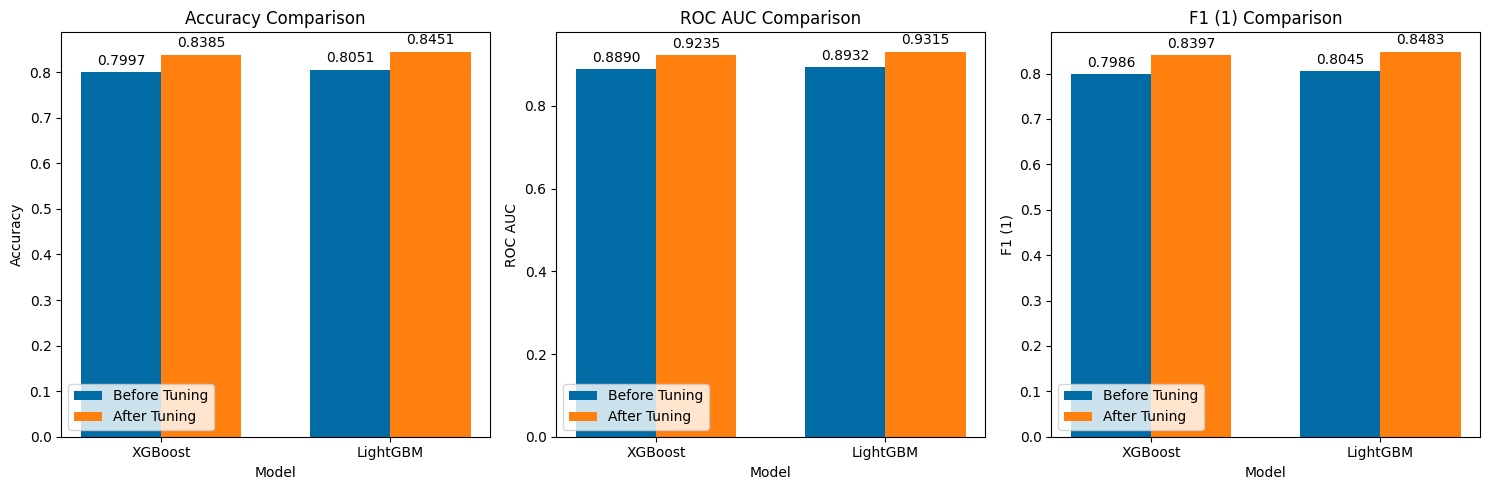

In [64]:
plot_metrics_comparison(overall_metrics_df, metrics_xgb, metrics_lgbm)

All metrics (accuracy, ROC AUC, and F1-score for class 1) improved for both LightGBM and XGBoost after tuning. 

LightGBM consistently shows slightly better results across all metrics compared to XGBoost.

**Feature importance using SHAP**

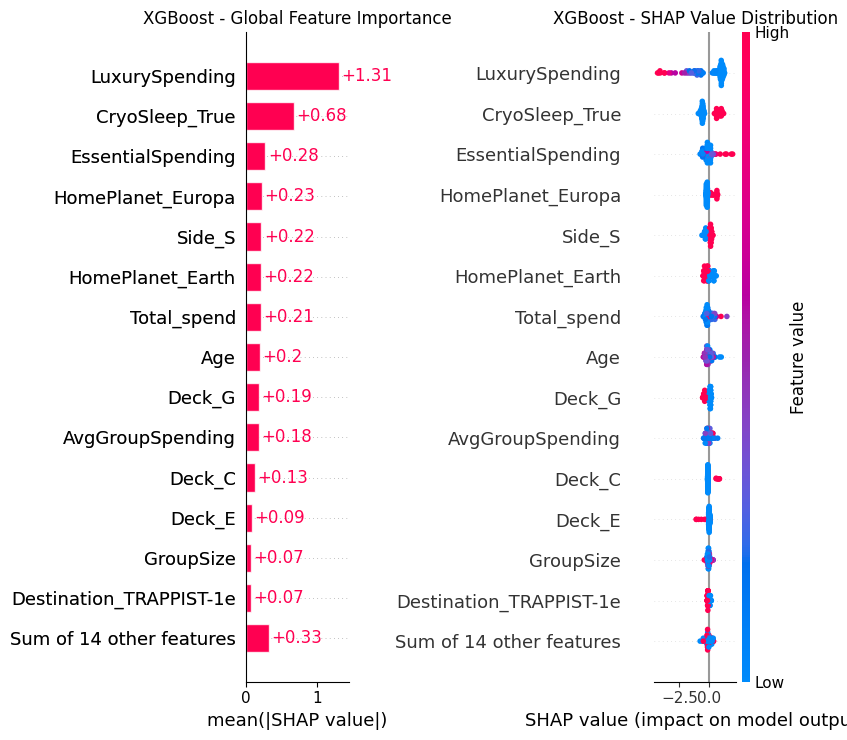

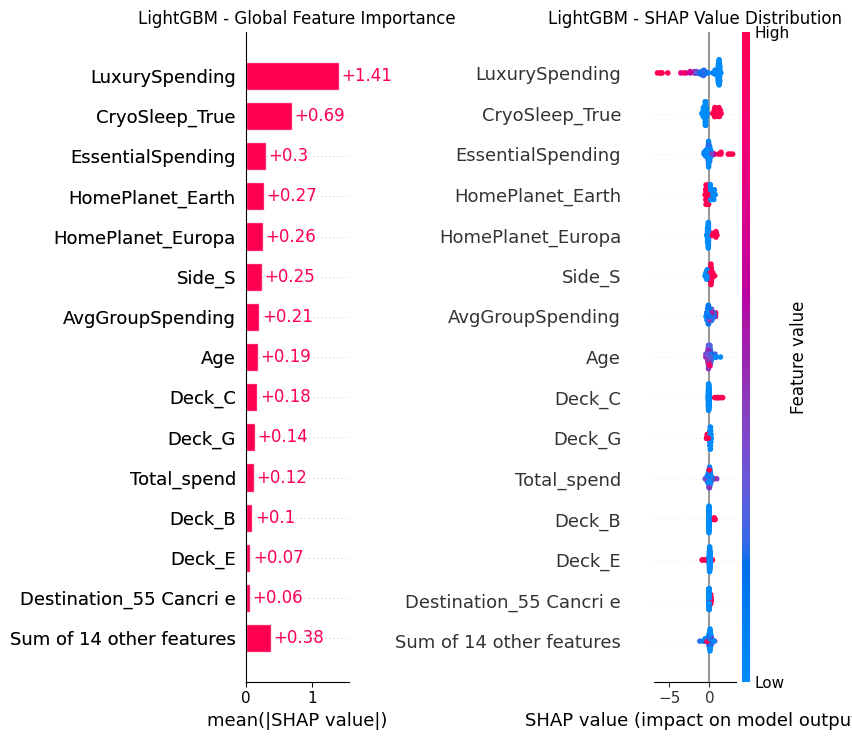

In [65]:
shap_xgb, xgb_feature_names = analyze_shap(
    best_model_xgb, preprocessor_xgb, X_train, "XGBoost"
)

shap_lgbm, lgbm_feature_names = analyze_shap(
    best_model_lgbm, preprocessor_lgbm, X_train, "LightGBM"
)

LuxurySpending (+1.31 / +1.41):

    This is consistently the most influential feature for both models.

    Higher luxury spending is strongly associated with an increased likelihood of not being 'Transported'.

CryoSleep_True (+0.68 / +0.69):

    This is the second most important feature, significantly contributing to the prediction.

    Being in cryosleep significantly increases the probability of being 'Transported'.

EssentialSpendings (+0.28 / +0.3):

    This category of spending also shows a positive contribution, suggesting that higher essential spending also increases the likelihood of being 'Transported'.

Home Planet Features (HomePlanet_Europa, HomePlanet_Earth):

    XGBoost: homePlanet_Europa (+0.23), HomePlanet_Earth (+0.22)

    LightGBM: HomePlanet_Earth (+0.27), homePlanet_Europa (+0.26)

    Both models show that originating from Europa positively influences the likelihood of being 'Transported'.
    
    Both models show that originating from Earth negatively influences the likelihood of being 'Transported'. 

Side_S (+0.22 / +0.25):

    This feature has a consistent positive impact, meaning that being on this specific side increases the probability of being 'Transported'.

Total_spend (+0.21 - XGBoost):

    XGBoost includes Total_spend as a moderately important factor, suggesting higher overall spending leads to increased transportation probability.

 AvgGroupSpending (+0.21 - LightGBM only):

    The average spending of a passenger's group also contributes positively to the likelihood of being transported.

Age (+0.2 - XGBoost only):

    XGBoost indicates that Age has a negative contribution. This implies that being older (within certain ranges) might slightly decrease the probability of being 'Transported'.

### E. Ensembling

We will choose two models XGBoost and LightGBM.

In [66]:
ensemble_model, ensemble_metrics = create_calibrated_ensemble(
    best_model_xgb,
    best_model_lgbm,
    preprocessor_xgb,
    preprocessor_lgbm,
    X_train,
    y_train,
)

print("\nFinal Ensemble Metrics:")
for k, v in ensemble_metrics.items():
    print(f"{k.capitalize()}: {v:.4f}")


Final Ensemble Metrics:
Accuracy: 0.8392
Roc_auc: 0.9302
F1: 0.8418


**Models comparison (Train data)**

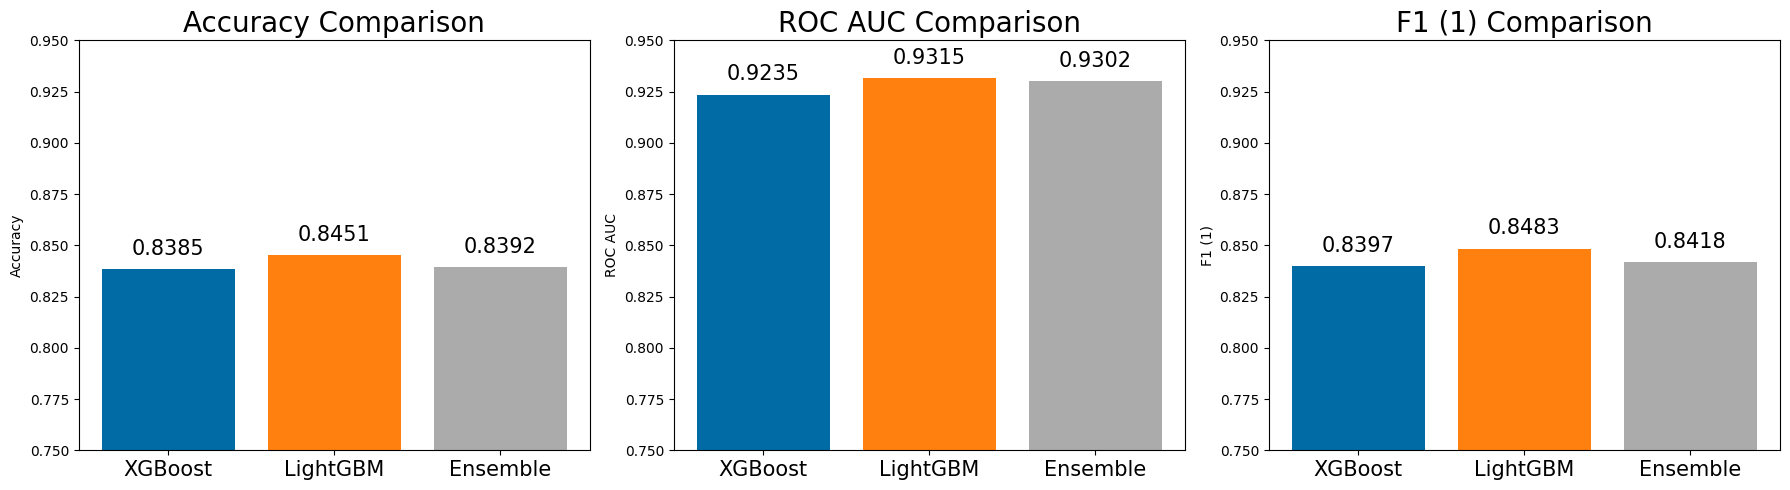

In [77]:
plot_model_metrics_comparison(metrics_xgb, metrics_lgbm, ensemble_metrics)

Ensemble model shows slightly better results than XGBoost, but worse than LightGBM in all main metrics (cross validation on X_train).

**Ensemble cross validation on training data**

In [78]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score),
}

cv_results = {
    metric: cross_val_score(ensemble_model, X_train, y_train, cv=cv, scoring=score)
    for metric, score in scoring.items()
}

print("\n=== Cross-Validation Metrics (Ensemble on Training Data) ===")
print(f"ROC AUC: {np.mean(cv_results['roc_auc']):.4f}")

oof_preds = np.zeros_like(y_train)
oof_true = np.array(y_train)

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    ensemble_model.fit(X_tr, y_tr)

    oof_preds[val_idx] = ensemble_model.predict(X_val)

print(classification_report(oof_true, oof_preds, digits=4))


=== Cross-Validation Metrics (Ensemble on Training Data) ===
ROC AUC: 0.8857
              precision    recall  f1-score   support

           0     0.8075    0.7885    0.7979      3452
           1     0.7963    0.8147    0.8054      3502

    accuracy                         0.8017      6954
   macro avg     0.8019    0.8016    0.8016      6954
weighted avg     0.8018    0.8017    0.8017      6954



**Models performance on Test data**


=== Test Set Evaluation: XGBoost ===
Accuracy: 0.7947
Roc_auc: 0.8878
F1: 0.7961
Precision: 0.7966
Recall: 0.7957


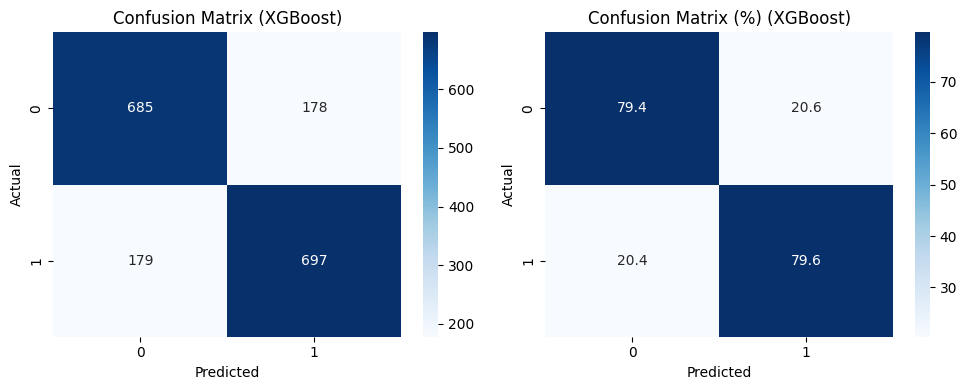


=== Test Set Evaluation: LightGBM ===
Accuracy: 0.7999
Roc_auc: 0.8952
F1: 0.8027
Precision: 0.7973
Recall: 0.8082


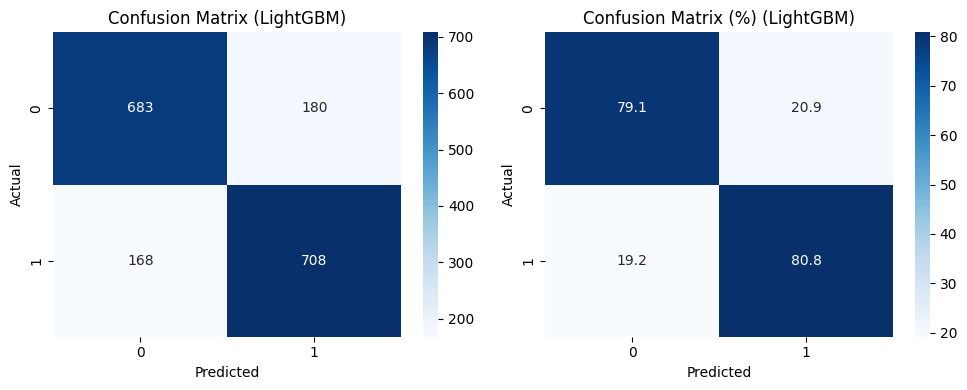


=== Test Set Evaluation: Ensemble ===
Accuracy: 0.8039
Roc_auc: 0.8917
F1: 0.8064
Precision: 0.8023
Recall: 0.8105


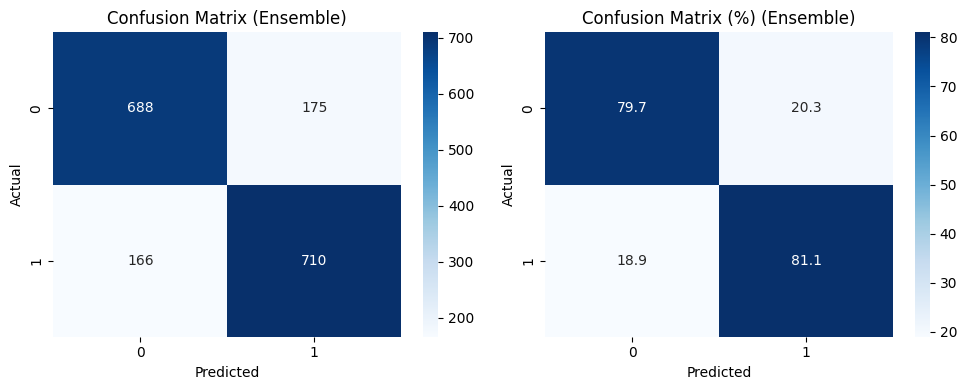

In [79]:
metrics_xgb_test = evaluate_model_on_test(
    best_model_xgb, preprocessor_xgb, X_test, y_test, "XGBoost"
)
metrics_lgbm_test = evaluate_model_on_test(
    best_model_lgbm, preprocessor_lgbm, X_test, y_test, "LightGBM"
)
metrics_ensemble_test = evaluate_model_on_test(
    ensemble_model, None, X_test, y_test, "Ensemble"
)

**Models comparison (Test data)**

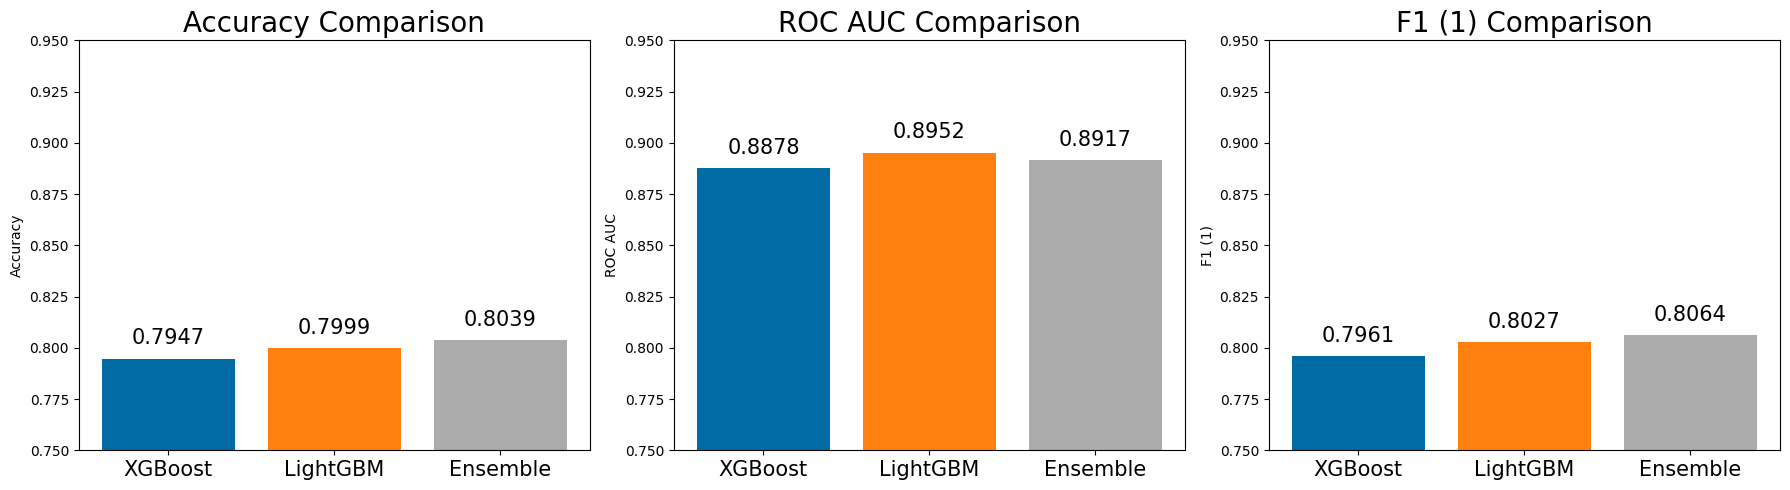

In [80]:
plot_model_metrics_comparison(
    metrics_xgb_test, metrics_lgbm_test, metrics_ensemble_test
)

The Ensemble model outperforms XGBoost across all main metrics. It also shows slightly better results than LightGBM in Accuracy and F1-score for class 1, while being very close to LightGBM in ROC AUC on the test set.

**Calibration plot for models**

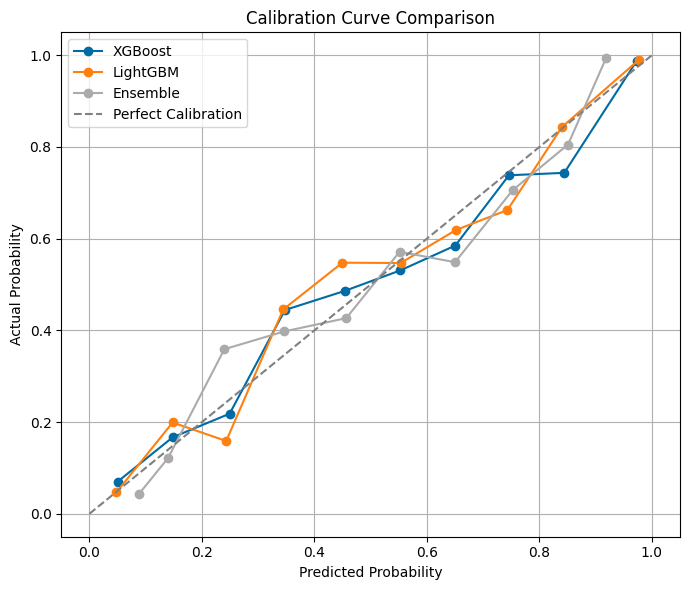

In [81]:
plot_calibration_comparison(
    models=[best_model_xgb, best_model_lgbm, ensemble_model],
    preprocessors=[preprocessor_xgb, preprocessor_lgbm, None],
    X_test=X_test,
    y_test=y_test,
    model_names=["XGBoost", "LightGBM", "Ensemble"],
)

The calibration curves show different values: predicted probabilities from approximately 0.27 to 0.57 are under confident, and then start to be overconfident. 

In the crucial area around 0.8, LightGBM demonstrates a slightly better result.

**Ensemble confusion matrix**


=== Test Set Evaluation: Ensemble ===
Accuracy: 0.8039
Roc_auc: 0.8917
F1: 0.8064
Precision: 0.8023
Recall: 0.8105


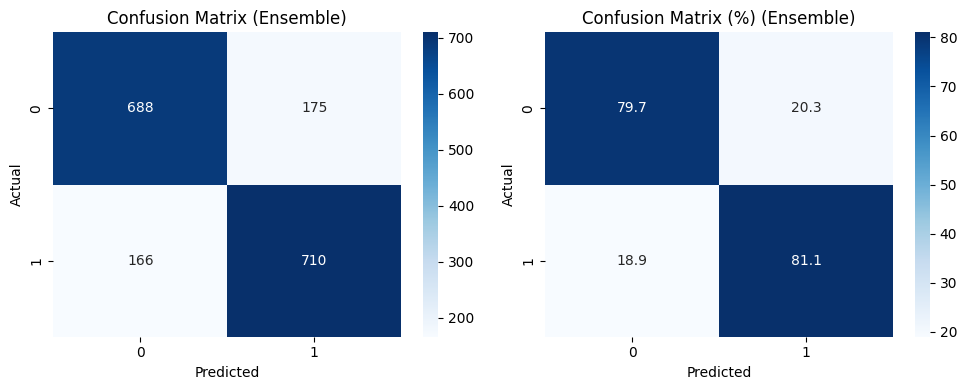

In [82]:
metrics_ensemble_test = evaluate_model_on_test(
    ensemble_model, None, X_test, y_test, "Ensemble"
)

Confusion matrix for ensemble model:
Class 0 (negative):

    682 correct predictions → 79% accuracy

    181 misclassified as class 1 → 21% error

Class 1 (positive):

    712 correct predictions → 81.3% accuracy

    164 misclassified as class 0 → 18.7% error

The model performs slightly better on identifying positives (class 1) than negatives — which suggests it’s well-tuned for detecting the positive class. Errors are balanced but lean toward more false positives than false negatives.

**Error analysis**

In [83]:
y_pred = ensemble_model.predict(X_test)
y_true = y_test.reset_index(drop=True)

comparison_df = pd.DataFrame({"Actual": y_true, "Predicted": y_pred})

false_positives = comparison_df[
    (comparison_df["Actual"] == 0) & (comparison_df["Predicted"] == 1)
]

false_negatives = comparison_df[
    (comparison_df["Actual"] == 1) & (comparison_df["Predicted"] == 0)
]
fp_cases = X_test.iloc[false_positives.index]
fn_cases = X_test.iloc[false_negatives.index]
print("\nFalse Positives Sample:")
print(fp_cases.describe(include="all"))

print("\nFalse Negatives Sample:")
print(fn_cases.describe(include="all"))


False Positives Sample:
       HomePlanet CryoSleep  Destination         Age    VIP        Group  \
count         172       171          171  172.000000    173   175.000000   
unique          3         2            3         NaN      2          NaN   
top         Earth      True  TRAPPIST-1e         NaN  False          NaN   
freq          132        92          127         NaN    171          NaN   
mean          NaN       NaN          NaN   25.651163    NaN  4483.291429   
std           NaN       NaN          NaN   15.107233    NaN  2844.227682   
min           NaN       NaN          NaN    0.000000    NaN    12.000000   
25%           NaN       NaN          NaN   17.000000    NaN  1954.500000   
50%           NaN       NaN          NaN   24.000000    NaN  4017.000000   
75%           NaN       NaN          NaN   35.000000    NaN  6973.500000   
max           NaN       NaN          NaN   63.000000    NaN  9261.000000   

         GroupSize      IsSolo Deck Side  LuxurySpending  Esse

False Positives (Predicted 1, Actually 0)

    Younger passengers (mean age ~25.6)

    Often from Earth, traveling to TRAPPIST-1e

    Almost half were in CryoSleep with no spending

    Lower average total spend (~740) and group travel (group size ~2.2)

    Strong presence of deck G, side S

The model tends to incorrectly flag low-spending, CryoSleep travelers in groups as positives, possibly because it associates these patterns with positive-class behavior.

False Negatives (Predicted 0, Actually 1)

    Older passengers (mean age ~30.9)

    Higher total spend (~1499) and luxury spending

    More often solo travelers (~69%) and not in CryoSleep

    Deck distribution leans toward deck F, also side S

The model misses some higher-spending solo travelers who are actually positives, possibly because their spending doesn’t match the profile it learned to associate with the positive class.

**Ensemble permutation importance**

              Feature  Importance
10     LuxurySpending    0.187867
11  EssentialSpending    0.033295
1           CryoSleep    0.030362
9                Side    0.018056
3                 Age    0.006728
8                Deck    0.005923
12        Total_spend    0.005290
14   AvgGroupSpending    0.004485
0          HomePlanet    0.003048
6           GroupSize    0.001265
2         Destination    0.000863
4                 VIP    0.000805
5               Group    0.000000
7              IsSolo    0.000000
13  CryoSleep_NoSpend    0.000000


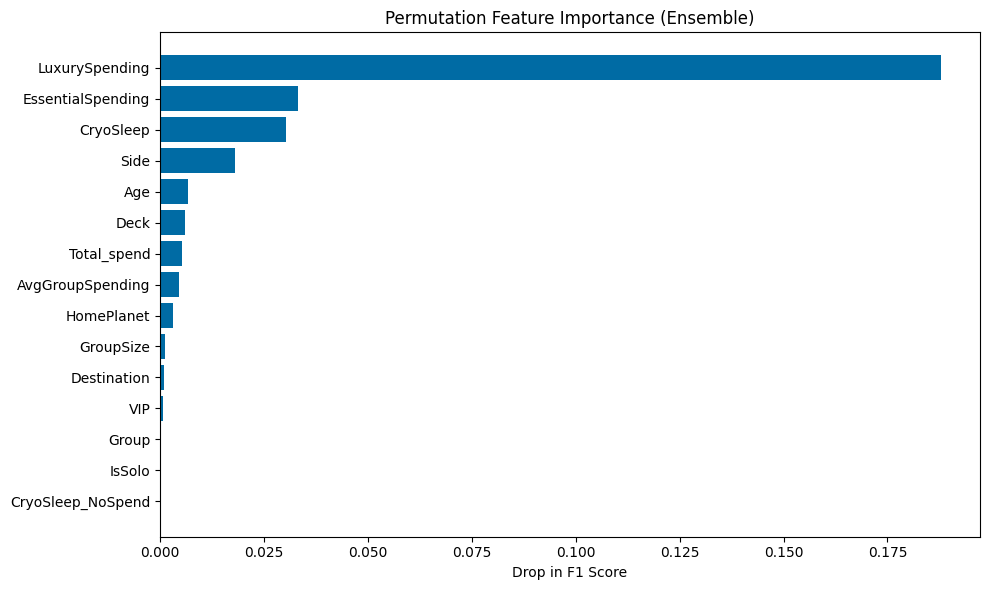

In [84]:
results = permutation_importance(
    ensemble_model, X_test, y_test, scoring="accuracy", n_repeats=10, random_state=42
)

importance_df = pd.DataFrame(
    {"Feature": X_test.columns, "Importance": results.importances_mean}
).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (Ensemble)")
plt.xlabel("Drop in F1 Score")
plt.tight_layout()
plt.show()

The ensemble's global Feature importance largely confirms the hierarchy of importance identified by the individual SHAP analyses of LightGBM and XGBoost. The top features are consistently:

    LuxurySpending, 
    EssentialSpending,
    CryoSleep.

Mid-Tier Features: Features like Side, Age, Deck, Total_spend, and AvgGroupSpending maintain their moderate influence across both analyses.

HomePlanet: The ensemble's single HomePlanet importance shows less impact on model seen in SHAP.

**Submiting model predictions to kaggle**

**Preparing test set**

In [85]:
test_df = pd.read_csv("Data/test.csv").copy()

test_df["Group"] = test_df["PassengerId"].str.split("_").str[0].astype(int)
group_sizes = test_df["Group"].value_counts()
test_df["GroupSize"] = test_df["Group"].map(group_sizes)
test_df["IsSolo"] = (test_df["GroupSize"] == 1).astype(int)
test_df["Deck"] = test_df["Cabin"].str[0]
test_df["Side"] = test_df["Cabin"].str[-1]
test_df["LuxurySpending"] = test_df["RoomService"] + test_df["Spa"] + test_df["VRDeck"]
test_df["EssentialSpending"] = test_df["FoodCourt"] + test_df["ShoppingMall"]
test_df["Total_spend"] = test_df["LuxurySpending"] + test_df["EssentialSpending"]
test_df["CryoSleep_NoSpend"] = (
    test_df["CryoSleep"] & (test_df["Total_spend"] == 0)
).astype(int)
test_df["AvgGroupSpending"] = test_df.groupby("Group")["Total_spend"].transform("mean")


X_test_final = test_df.drop(
    columns=[
        "Name",
        "PassengerId",
        "Cabin",
        "RoomService",
        "Spa",
        "VRDeck",
        "FoodCourt",
        "ShoppingMall",
    ]
)

**LightGBM**

In [86]:
optimal_iterations = 2000

final_model_lgbm = LGBMClassifier(
    **metrics_lgbm["best_params"],
    n_estimators=optimal_iterations,
    random_state=42,
    n_jobs=1,
    verbose=-1
)

pipe_lgbm = Pipeline([("preprocessor", preprocessor), ("classifier", final_model_lgbm)])

pipe_lgbm.fit(X_train, y_train)

predictions_lgbm = pipe_lgbm.predict(X_test_final)

submission_lgbm = pd.DataFrame(
    {
        "PassengerId": test_df["PassengerId"],
        "Transported": predictions_lgbm.astype(bool),
    }
)

submission_lgbm.to_csv("submission_lightgbm.csv", index=False)

LightGBM gets 0.80009 in kaggle competition (>0.79 achieved).

**Ensemble**

In [87]:
ensemble_preds = ensemble_model.predict(X_test_final)

submission_ensemble = pd.DataFrame(
    {
        "PassengerId": test_df["PassengerId"],
        "Transported": ensemble_preds.astype(bool),
    }
)

submission_ensemble.to_csv("submission_ensemble.csv", index=False)

Ensemble gets 0.78910 in kaggle competition (>0.79 not achieved). Best result for ensemble 0.79518.

### F. FlaMl - Using AutoMl tools

In [88]:
warnings.filterwarnings("ignore")

logging.getLogger("flaml.automl").setLevel(logging.ERROR)

automl = AutoML()
automl_settings = {
    "time_budget": 3600,
    "metric": "accuracy",
    "task": "classification",
    "log_file_name": None,
    "verbose": 0,
}

automl.fit(X_train=X_train, y_train=y_train, **automl_settings)
predictions = automl.predict(X_test)

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


In [105]:
print("Best model type:", automl.best_estimator)
print("Best configuration:", automl.best_config)
print("Best trained model object:", automl.model)

Best model type: catboost
Best configuration: {'early_stopping_rounds': 12, 'learning_rate': 0.04367368757574133, 'n_estimators': 8192}
Best trained model object: <flaml.automl.model.CatBoostEstimator object at 0x00000210C2C65AD0>


**Evaluating FlaMl on Train set**

In [89]:
train_preds = automl.predict(X_train)
train_probs = automl.predict_proba(X_train)[:, 1]

acc = accuracy_score(y_train, train_preds)
auc = roc_auc_score(y_train, train_probs)
f1 = f1_score(y_train, train_preds, pos_label=1)

print("Accuracy:", round(acc, 4))
print("ROC AUC:", round(auc, 4))
print("F1 Score (label=1):", round(f1, 4))

Accuracy: 0.8185
ROC AUC: 0.91
F1 Score (label=1): 0.8218


**Submiting model predictions to kaggle**

In [91]:
predictions = automl.predict(X_test_final)
submission = pd.DataFrame(
    {
        "PassengerId": test_df["PassengerId"],
        "Transported": predictions.astype(bool).astype(str),
    }
)

submission.to_csv("submission_flaml.csv", index=False)

FlaMl gets 0.80476 in kaggle competition (>0.79 achieved). Best result for FlaMl 0.80664.

**Feature importance for FlaMl**

In [93]:
importance_df = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": automl.model.feature_importances_}
).sort_values(by="Importance", ascending=False)

print(importance_df)

              Feature  Importance
10     LuxurySpending   27.488210
0          HomePlanet   14.828382
4                 VIP   14.565148
1           CryoSleep   10.036148
11  EssentialSpending    9.470220
7              IsSolo    6.767102
5               Group    5.974840
6           GroupSize    2.473471
14   AvgGroupSpending    2.450473
12        Total_spend    2.447008
2         Destination    2.411637
3                 Age    0.475178
8                Deck    0.463256
9                Side    0.148926
13  CryoSleep_NoSpend    0.000000


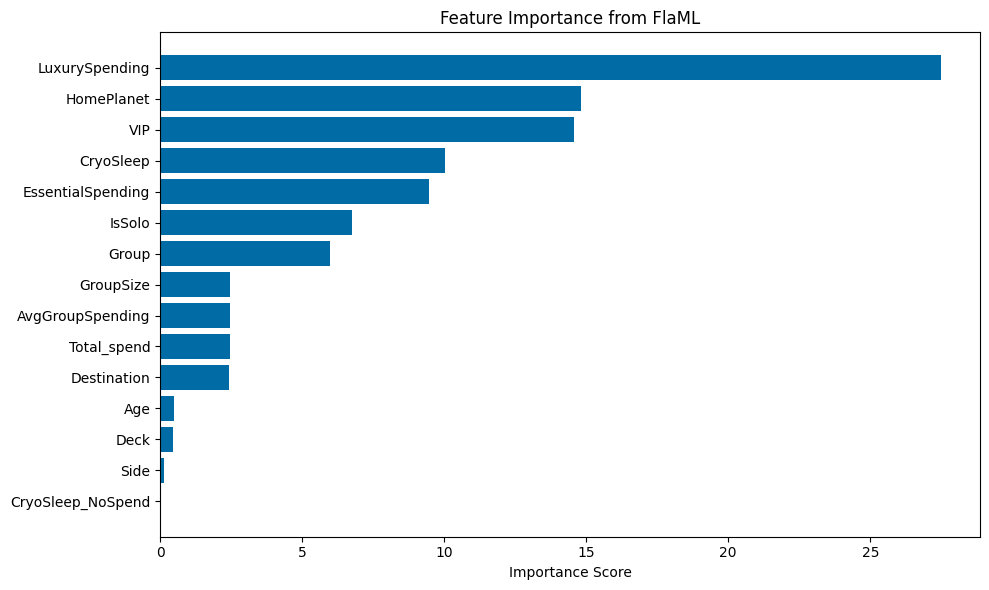

In [97]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance from FlaML")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

LuxurySpending remains the most dominant feature by a significant margin in both global importance and SHAP (LightGBM)

CryoSleep and EssentialSpending also consistently appear as strong predictors.

HomePlanet and VIP show a much higher overall importance (around 14-15%) in this new list compared to their more moderate or lower influence in the individual SHAP analyses.

IsSolo and Group now have notable importance (6-7%) whereas they had 0 importance in the previous list.

Side has dropped significantly in this new list.

**Classification report on Test set, confusion matrix**

FlaMl comparison to ensemble.

In [98]:
predictions_fla = automl.predict(X_test)
print(classification_report(y_test, predictions_fla, digits=4))

              precision    recall  f1-score   support

           0     0.8009    0.7833    0.7920       863
           1     0.7911    0.8082    0.7995       876

    accuracy                         0.7959      1739
   macro avg     0.7960    0.7958    0.7958      1739
weighted avg     0.7960    0.7959    0.7958      1739




=== Test Set Evaluation: Ensemble ===
Accuracy: 0.8039
Roc_auc: 0.8917
F1: 0.8064
Precision: 0.8023
Recall: 0.8105


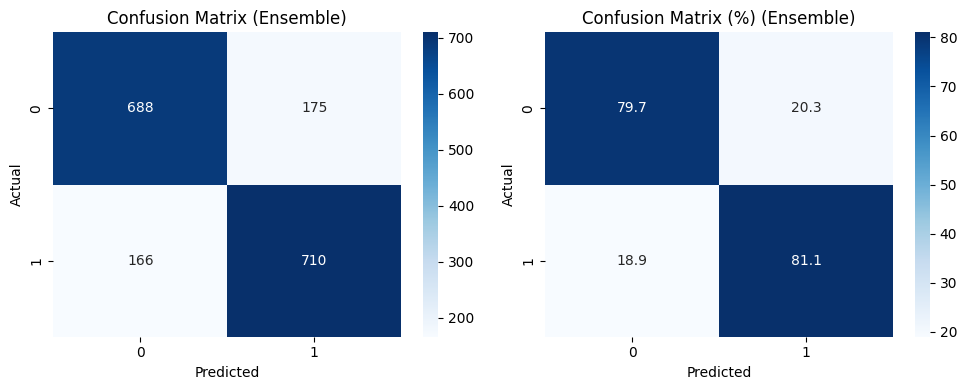

In [101]:
metrics_ensemble_test = evaluate_model_on_test(
    ensemble_model, None, X_test, y_test, "Ensemble"
)

Text(0.5, 1.0, 'Confusion Matrix')

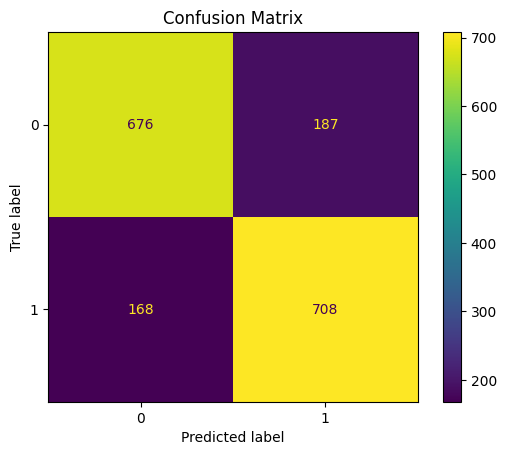

In [103]:
cm = confusion_matrix(y_test, automl.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")

FlaMl shows slightly worse metric results on test set (main metrics, confusion matrix), but much better results on predictions (0.80476 to 0.7891)

**Calibration plot**

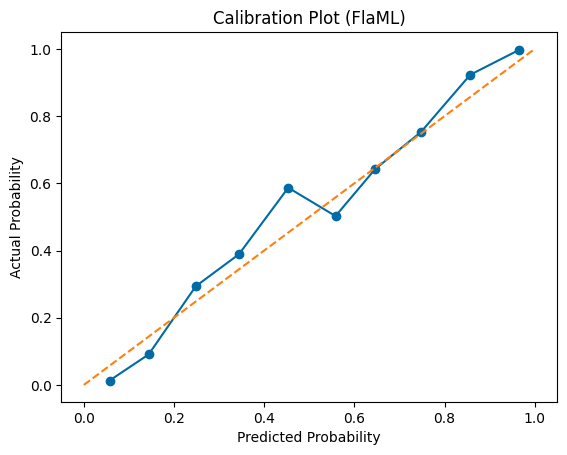

In [104]:
probs = automl.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Calibration Plot (FlaML)")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.show()

FlaMl is better calibrated near 0.8, or even slightly under confident, compared to LighGBM model which was overconfident.

## 5. Conclusion

Key Findings:

    LightGBM as a Strong Baseline: 
    Untuned LightGBM was the best performing individual model initially, and its tuned version achieved very competitive results on the test set and a strong score in the kaggle competition (0.80009).

    Impact of Tuning: 
    Hyperparameter tuning significantly improved the performance of both LightGBM and XGBoost, underscoring the importance of this step in the ML pipeline.

    Ensemble Performance Nuance: 
    While the ensemble showed strong metrics on the internal test set, its lower performance on the public kaggle leaderboard (0.78910) suggests potential issues with overfitting to the internal validation split, or that the simple averaging in the ensemble did not generalize as well to unseen public test data.

    Critical Features Identified: 
    LuxurySpending, CryoSleep, and EssentialSpending are consistently the most influential features across all models and interpretability methods, indicating their strong predictive power for passenger transportation.

    AutoML's Effectiveness: 
    The FlaML AutoML solution achieved the highest kaggle score (0.80476, best on first attempt 0.80664), demonstrating the efficiency and effectiveness of automated methods in finding optimal model configurations and potentially better generalization.


Suggestions for Improvement:

Re-evaluate Ensemble Strategy:

        Weighted Voting: Explore weighted voting in the VotingClassifier based on individual model performance or OOF probabilities.

        Diverse Models: Include more diverse base models in the ensemble (e.g., a Logistic Regression, a simpler tree, or even a neural network) to increase predictive diversity.

Advanced Feature Engineering:

        Interaction Features: Explicitly create interaction features between highly important variables.

        Categorical Encoding Refinement: Explore more advanced categorical encoding techniques beyond OneHotEncoder (e.g., Target Encoding, CatBoost Encoder) for features like HomePlanet, Destination, Deck, Side to potentially capture more nuanced information.

Explore Other AutoML Frameworks: 
        
         Experiment with other AutoML libraries (e.g., AutoGluon, H2O.ai) as they often include advanced ensemble techniques and can achieve high performance with less manual effort.

Error Analysis on Misclassified Samples:

        Analyze the characteristics of samples where the ensemble performed poorly (e.g., cases where LightGBM was correct but the ensemble was wrong) to identify patterns or edge cases that the ensemble struggles with.